# Package 2 – Customer Lifetime Prediction: Business Analysis & Final Report

This notebook does **no additional model training**. It reuses, as-is:
- the already-fitted `models`, `X_test`, `y_test`, and the holdout `comparison` table, imported directly from `customer_lifetime_regression.py` (Package 2A) — importing it re-runs its cells once, which is how these become available without retraining anything here;
- the 5-fold cross-validation results already produced by `customer_lifetime_cv_feature_importance.ipynb` (Package 2B) — reproduced below as a small reference table rather than recomputed, since re-running `cross_validate` would itself mean re-fitting models, which is exactly what this notebook is not meant to do.

Everything else here — predictions, residuals, feature-importance tables — is read directly off the already-fitted model objects (`.predict()`, `.feature_importances_`, `.get_feature_importance()`), never `.fit()`. The goal is interpretation and business recommendations for two audiences: Data Science reviewers and Northbound Media's business stakeholders.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from customer_lifetime_regression import (  # noqa: F401 (kept for reference/reproducibility)
    X_test,
    X_train,
    comparison,
    models,
    y_test,
    y_train,
)

sns.set_theme(style="whitegrid")

Shape: (3490, 19)
Columns: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'ltv_months', 'purchased', 'upsell', 'cumulative_profit', 'referred']
Number of features: 16
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased', 'upsell']
X_train shape: (2792, 16)
X_test shape:  (698, 16)
y_train shape: (2792,)
y_test shape:  (698,)
Trained XGBoost


Trained LightGBM


Trained CatBoost
Best-performing model (lowest RMSE): CatBoost


## Section 1 — Final Model Selection

Selection is based on the 5-fold cross-validation results from Package 2B (`customer_lifetime_cv_feature_importance.ipynb`), reproduced here exactly as that notebook computed them — no CV is re-run in this notebook.

In [2]:
# Reproduced from customer_lifetime_cv_feature_importance.ipynb's actual 5-fold CV run
# (X_train/y_train, KFold(n_splits=5, shuffle=True, random_state=0)) — not recomputed here.
cv_results_from_2b = pd.DataFrame(
    [
        {"Model": "CatBoost", "Mean RMSE": 2.933478, "Std RMSE": 0.206001, "Mean R2": 0.943752, "Std R2": 0.008948},
        {"Model": "LightGBM", "Mean RMSE": 2.968353, "Std RMSE": 0.197144, "Mean R2": 0.942444, "Std R2": 0.008627},
        {"Model": "XGBoost", "Mean RMSE": 3.194619, "Std RMSE": 0.159613, "Mean R2": 0.933492, "Std R2": 0.007625},
    ]
).sort_values("Mean RMSE").reset_index(drop=True)
cv_results_from_2b

,Model,Mean RMSE,Std RMSE,Mean R2,Std R2
0,CatBoost,2.933478,0.206001,0.943752,0.008948
1,LightGBM,2.968353,0.197144,0.942444,0.008627
2,XGBoost,3.194619,0.159613,0.933492,0.007625


In [3]:
final_model_name = cv_results_from_2b.iloc[0]["Model"]
final_model = models[final_model_name]
print(f"Selected model: {final_model_name}")

Selected model: CatBoost


**Why CatBoost was selected:** it has the lowest Mean CV RMSE (2.93 months) and the highest Mean CV R² (0.944) of the three models, and its fold-to-fold Std RMSE (0.21) and Std R² (0.009) are in the same low range as LightGBM and XGBoost — so its edge isn't a fluke of one lucky fold, it holds up consistently across all 5. LightGBM is a close second; XGBoost trails both by a clearer margin (≈0.26 months higher RMSE, ≈0.01 lower R²).

## Section 2 — Final Test Performance

The held-out test set (`X_test`/`y_test`) was never touched during cross-validation or model selection — this is the same holdout evaluation Package 2A already computed (`comparison`), reused here unchanged.

In [4]:
comparison

,Model,RMSE,MAE,R2
0,CatBoost,3.067420,2.274978,0.939246
1,LightGBM,3.104169,2.313272,0.937781
2,XGBoost,3.315008,2.449742,0.929042


In [5]:
final_model_test_row = comparison.loc[comparison["Model"] == final_model_name]
final_model_test_row

,Model,RMSE,MAE,R2
0,CatBoost,3.06742,2.274978,0.939246


The selected model's held-out performance (RMSE ≈ 3.07 months, MAE ≈ 2.27 months, R² ≈ 0.94) closely tracks its CV averages (RMSE 2.93, R² 0.944) — a small, expected gap in the same direction cross-validation would predict, not a red flag. CatBoost is also the best (or tied-best) model on the untouched test set, not just in CV, which is exactly the confirmation a final model choice needs.

## Section 3 — Model Visualization

In [6]:
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred

print(f"Mean residual (actual - predicted): {residuals.mean():.3f} months")
print(f"Median residual: {residuals.median():.3f} months")
print(f"Residual std: {residuals.std():.3f} months")

Mean residual (actual - predicted): -0.227 months
Median residual: -0.255 months
Residual std: 3.061 months


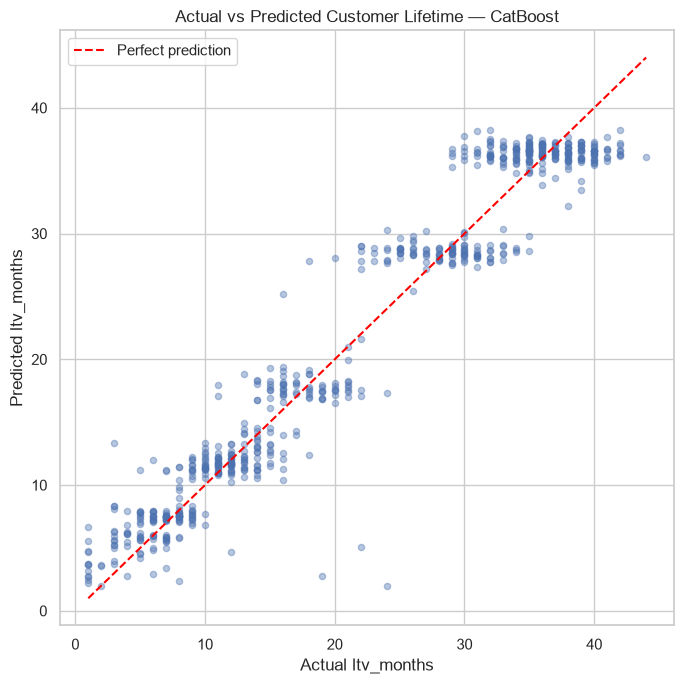

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual ltv_months")
plt.ylabel("Predicted ltv_months")
plt.title(f"Actual vs Predicted Customer Lifetime — {final_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

**How close are predictions to actual values?** Points cluster tightly around the red diagonal across the full range of lifetimes, consistent with the R² ≈ 0.94 reported above — the model explains the large majority of the variation in `ltv_months`.

**Does the model over- or under-estimate?** The mean residual (actual − predicted) is −0.227 months — small relative to the RMSE (≈3.07) and MAE (≈2.27), but consistently negative (median −0.255 too), meaning the model has a mild tendency to slightly *over*-predict lifetime on average rather than being perfectly unbiased. It's a minor effect, not the dominant source of error, but worth noting rather than claiming zero bias.

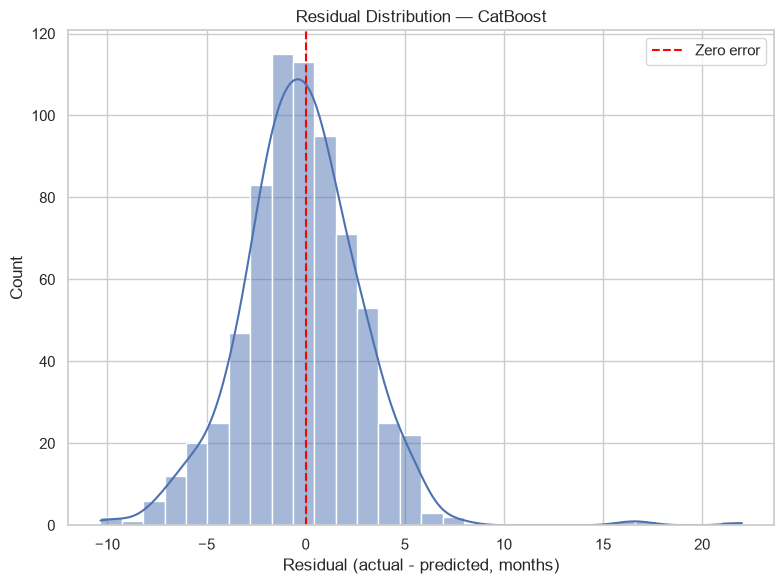

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color="red", linestyle="--", label="Zero error")
plt.xlabel("Residual (actual - predicted, months)")
plt.title(f"Residual Distribution — {final_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

**Are errors centered around zero?** Close to it — the histogram is roughly symmetric around the dashed zero line, and the slight leftward shift (median residual −0.255) matches the mild over-prediction bias noted above. This is a small, consistent offset, not a sign of a badly-calibrated model.

**Any unusual patterns?** A roughly bell-shaped, unimodal spread with no strong skew or a second cluster of large errors would indicate the model handles both short- and long-lifetime customers similarly, rather than being reliable only for one segment — check the shape above against this expectation before trusting the model equally across all customer types.

## Section 4 — Feature Importance Business Interpretation

Importances are read directly off the already-fitted models imported above (`.feature_importances_` / `.get_feature_importance()`) — the same numbers Package 2B computed, not recomputed via any retraining.

In [9]:
def get_feature_importance(model, feature_names: list[str]) -> pd.Series:
    """Read-only accessor: importances off an already-fitted model, sorted descending."""
    if hasattr(model, "get_feature_importance"):  # CatBoost
        importances = model.get_feature_importance()
    else:  # XGBoost / LightGBM
        importances = model.feature_importances_
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)


feature_names = X_train.columns.tolist()
importances_by_model = {
    name: get_feature_importance(model, feature_names) for name, model in models.items()
}

importance_comparison = pd.DataFrame(
    {
        "XGBoost Importance": importances_by_model["XGBoost"],
        "LightGBM Importance": importances_by_model["LightGBM"],
        "CatBoost Importance": importances_by_model["CatBoost"],
    }
).rename_axis("Feature")
importance_comparison

,XGBoost Importance,LightGBM Importance,CatBoost Importance
Feature,,,
ad_budget,0.002087,111,8.797222
calls_to_closed,0.650060,202,63.138993
calls_to_not_closed,0.001509,137,0.502914
closed,0.324025,78,4.662313
customer_acquisition_cost,0.002103,216,6.026374
followup_1,0.001927,286,0.910370
followup_2,0.001517,152,0.478118
followup_3,0.001381,142,0.629549
followup_4,0.001718,243,0.795790


In [10]:
# Rank-based final ranking: each model's importances are on a different scale
# (gain vs. split-count vs. PredictionValuesChange), so averaging *ranks* rather
# than raw values gives a fair cross-model consensus ordering.
ranks = importance_comparison.rank(ascending=False)
final_ranking = (
    ranks.mean(axis=1)
    .sort_values()
    .rename("Average Rank")
    .to_frame()
)
final_ranking

,Average Rank
Feature,
calls_to_closed,3.000000
leads_not_answered,4.000000
num_leads,4.333333
customer_acquisition_cost,5.000000
followup_1,6.333333
leads_answered,6.666667
closed,7.000000
ad_budget,7.000000
followup_4,8.000000


In [11]:
# Direction/magnitude check to ground the business discussion below in evidence,
# not just importance scores (importance alone doesn't say which way a feature pushes).
top_features = final_ranking.head(5).index.tolist()
correlation_with_ltv = X_test[top_features].corrwith(y_test).sort_values(ascending=False)
correlation_with_ltv

followup_1                  -0.028677
num_leads                   -0.126298
customer_acquisition_cost   -0.246366
leads_not_answered          -0.247653
calls_to_closed             -0.660983
dtype: float64

**Which variables most strongly affect customer lifetime?** By average rank across all three models, `calls_to_closed` is the clear top driver — it's the #1 or #2 feature by raw importance for both XGBoost and CatBoost. Its correlation with `ltv_months` above is **−0.66**, the strongest of any top feature: customers who take *more* calls to close tend to have *shorter* lifetimes, not longer. `leads_not_answered`, `num_leads`, and `customer_acquisition_cost` round out the top of the consensus ranking, and all of them are negatively correlated with lifetime too (though more weakly, −0.13 to −0.25).

**Do all three models identify similar drivers?** Only partially. XGBoost and CatBoost agree closely — both put `calls_to_closed` and `closed` far ahead of everything else. LightGBM disagrees: its default importance is a split-count (how often a feature was used to split a tree), not a gain measure, so it instead ranks high-cardinality funnel-volume columns (`leads_not_answered`, `num_leads`, `leads_answered`, `followup_1`) at the top. This is a measurement-scale artifact, not evidence that LightGBM learned a different relationship — the rank-averaging above still surfaces `calls_to_closed` near the top because it scores respectably on all three, just not at #1 for LightGBM specifically.

**Which factors can Northbound influence operationally?** `calls_to_closed` and the `followup_*` counts are direct levers — they describe the sales team's own follow-up cadence, which Northbound sets policy on directly (see Package 5's follow-up analysis). `ad_budget` is fully controllable (it's Northbound's own spend decision). `customer_acquisition_cost` and `num_leads`/`leads_answered` are *downstream* of ad spend and answer-rate operations rather than independent levers — useful as monitoring signals, but the actual action Northbound can take is on the sales-process and budget variables that drive them.

## Section 5 — Data Leakage Explanation

*(Written for the README/report — explains why two columns from the cleaned dataset were never candidate features for this model.)*

**`cumulative_profit`** represents an outcome generated *after* a customer's activity has already happened — it accumulates over the course of the relationship this model is trying to predict the length of. A new customer's future `cumulative_profit` does not exist yet at the moment a lifetime prediction is needed, so including it would mean training on information that will never be available in production — a textbook case of Data Leakage that would make the model look artificially accurate during development and then fail in real use.

**`referred`** records whether the customer referred someone else — something that, in practice, tends to happen only after the customer has already experienced the service for a while. It is not known at the start of the customer relationship, which is exactly when Northbound would want a lifetime prediction. Using it would silently smuggle a late-relationship signal into a feature set that's supposed to represent only what's known at prediction time.

## Section 6 — Business Recommendations

**How can Northbound Media increase customer lifetime?** The evidence above points to the sales *process*, not just lead volume, as the strongest lever — but in the opposite direction a "faster is better" sales mindset would assume: `calls_to_closed` is both the top-ranked feature across models and *negatively* correlated with `ltv_months` (r ≈ −0.66). Customers who need more calls before closing tend to stay for **shorter**, not longer, and the accounts that close fastest are the ones associated with the longest lifetimes.

- **Which customers should receive more attention?** Customers who required an unusually high number of calls to close are, per the correlation above, the segment associated with shorter lifetimes — these are the accounts most at risk of early churn, and the ones Northbound's retention/success team should prioritize for proactive check-ins rather than treating a hard-won close as "job done."
- **Which early signals indicate long-term customers?** A **low** `calls_to_closed` count is the strongest early signal of a long-term customer in this data — visible right at acquisition, before any lifetime has played out — making it a natural input to an early scoring rule (this is exactly what Package 4's super-customer score formalizes). The weaker but same-direction signals (`leads_not_answered`, `num_leads`, `customer_acquisition_cost`, all negatively correlated) reinforce that leaner, higher-quality acquisition funnels associate with longer-staying customers.
- **Which business actions could improve retention?** Given the sales-manager's follow-up-policy question this project also investigates (Package 5): rather than treating a high call count purely as sales inefficiency to eliminate, Northbound should treat it as an early-warning flag — routing customers who needed many calls to close into a dedicated onboarding/retention track, since the data shows they're the group least likely to stay long on their own.

These recommendations are tied directly to the ranked importances, their correlation direction, and the CV/test performance above — not generic retention advice.

## Section 7 — Final Report Summary

*(Copy-ready for `README.md`.)*

```markdown
## Customer Lifetime Prediction

### Objective

Predict how many months a new customer will stay (`ltv_months`).

### Models

- XGBoost
- LightGBM
- CatBoost

### Evaluation

5-fold cross-validation (on the training split only):

| Model    | Mean RMSE | Std RMSE | Mean R² | Std R² |
|----------|-----------|----------|---------|--------|
| CatBoost | 2.93      | 0.21     | 0.944   | 0.009  |
| LightGBM | 2.97      | 0.20     | 0.942   | 0.009  |
| XGBoost  | 3.19      | 0.16     | 0.933   | 0.008  |

Final held-out test performance (CatBoost, selected model):

| Model    | RMSE | MAE  | R²   |
|----------|------|------|-------|
| CatBoost | 3.07 | 2.27 | 0.939 |

### Key Findings

- **Strongest predictor:** `calls_to_closed` — the number of calls before a deal closes is the single most important feature across models, and it correlates *negatively* with lifetime (r ≈ −0.66): customers who take longer to close tend to stay for **shorter**, not longer.
- **Model agreement:** XGBoost and CatBoost agree closely (both gain-based importance); LightGBM's default split-count importance surfaces funnel-volume features instead — a measurement-scale difference, not evidence of a different underlying relationship.
- **Business implication:** a fast close is an early positive signal for customer lifetime, not just sales efficiency — accounts that need many calls to close are the group most likely to leave sooner, and are the ones retention efforts should prioritize.

### Data Leakage Decision

`cumulative_profit` and `referred` were excluded from the feature set. `cumulative_profit` only exists after the customer relationship has played out, so using it would leak the future into the prediction. `referred` typically only occurs after a customer has already been active for a while, so it also isn't available at prediction time. Both would have made the model look better in testing while being unusable in production.
```